In [1]:
import os
import io
import zipfile
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Price

In [2]:
def calc_filtered_mid(df, threshold=15):
    """
    Calculates a filtered mid-price, safely ignoring NaN values 
    in the order book data.
    """
    # 1. Extract Arrays
    b_px = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].values
    b_vol = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].values
    a_px = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].values
    a_vol = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].values

    # 2. Safely handle volume NaNs (treat missing volume as 0)
    b_vol_safe = np.nan_to_num(b_vol, nan=0.0)
    a_vol_safe = np.nan_to_num(a_vol, nan=0.0)

    b_mask = b_vol_safe >= threshold
    a_mask = a_vol_safe >= threshold

    # 3. Process Bids
    valid_b_px = np.where(b_mask, b_px, -np.inf)
    # Use nanmax to ignore NaNs in the price columns
    best_b_px_filtered = np.nanmax(valid_b_px, axis=1)
    
    fallback_b_idx = np.argmax(b_vol_safe, axis=1)
    fallback_b_px = b_px[np.arange(len(b_px)), fallback_b_idx]
    
    final_bid = np.where(np.any(b_mask, axis=1), best_b_px_filtered, fallback_b_px)

    # 4. Process Asks
    valid_a_px = np.where(a_mask, a_px, np.inf)
    # Use nanmin to ignore NaNs in the price columns
    best_a_px_filtered = np.nanmin(valid_a_px, axis=1)
    
    fallback_a_idx = np.argmax(a_vol_safe, axis=1)
    fallback_a_px = a_px[np.arange(len(a_px)), fallback_a_idx]
    
    final_ask = np.where(np.any(a_mask, axis=1), best_a_px_filtered, fallback_a_px)

    # 5. Calculate the filtered mid price
    filtered_mid = (final_bid + final_ask) / 2
    filtered_mid = pd.Series(filtered_mid).ffill()

    return filtered_mid

In [3]:
price = pd.read_csv('../data/raw/round_4/prices_round_4_day_1.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_hydro = price[price['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
price_1 = pd.read_csv('../data/raw/round_4/prices_round_4_day_2.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_hydro_1 = price_1[price_1['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
price_2 = pd.read_csv('../data/raw/round_4/prices_round_4_day_3.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_hydro_2 = price_2[price_2['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)

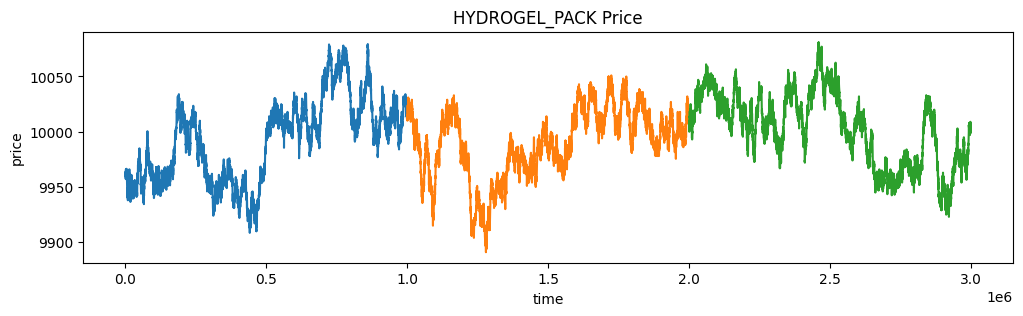

In [4]:
plt.figure(figsize=(12, 3))
plt.plot(price_hydro['timestamp'], price_hydro['mid_price'])
plt.plot(price_hydro_1['timestamp'] + 1000000, price_hydro_1['mid_price'])
plt.plot(price_hydro_2['timestamp'] + 2000000, price_hydro_2['mid_price'])
plt.title('HYDROGEL_PACK Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

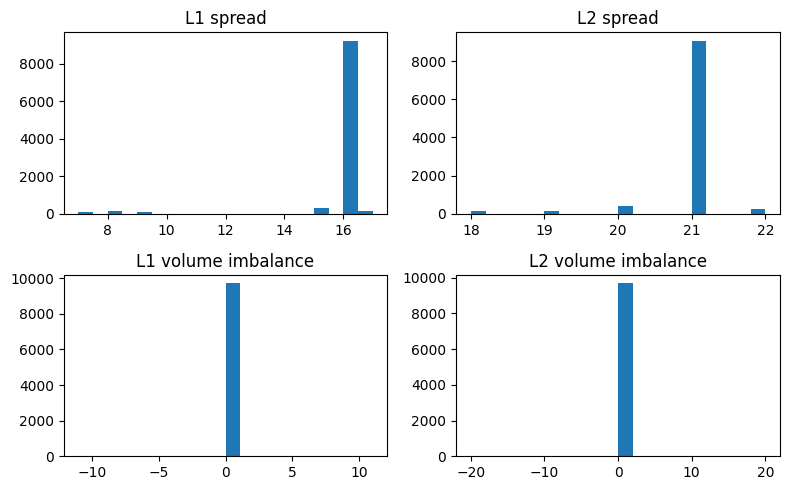

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_hydro['ask_price_1'] - price_hydro['bid_price_1'], bins=20)
ax[0, 1].hist(price_hydro['ask_price_2'] - price_hydro['bid_price_2'], bins=20)
ax[1, 0].hist(price_hydro['ask_volume_1'] - price_hydro['bid_volume_1'], bins=20)
ax[1, 1].hist(price_hydro['ask_volume_2'] - price_hydro['bid_volume_2'], bins=20)
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

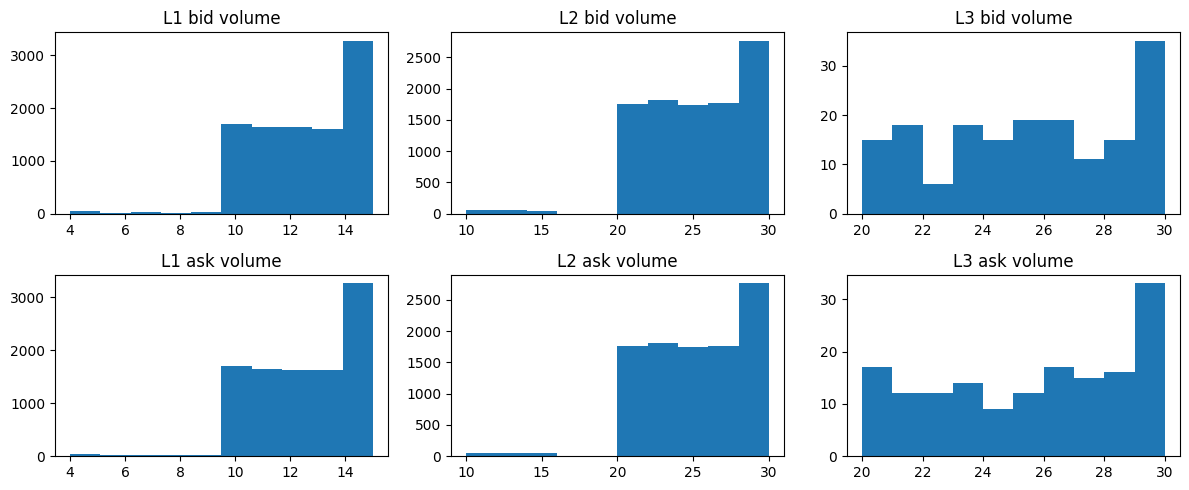

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_hydro['bid_volume_1'])
ax[0, 1].hist(price_hydro['bid_volume_2'])
ax[0, 2].hist(price_hydro['bid_volume_3'])
ax[1, 0].hist(price_hydro['ask_volume_1'])
ax[1, 1].hist(price_hydro['ask_volume_2'])
ax[1, 2].hist(price_hydro['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [7]:
price_hydro = price_hydro.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=10))
price_hydro_1 = price_hydro_1.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=10))
price_hydro_2 = price_hydro_2.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=10))

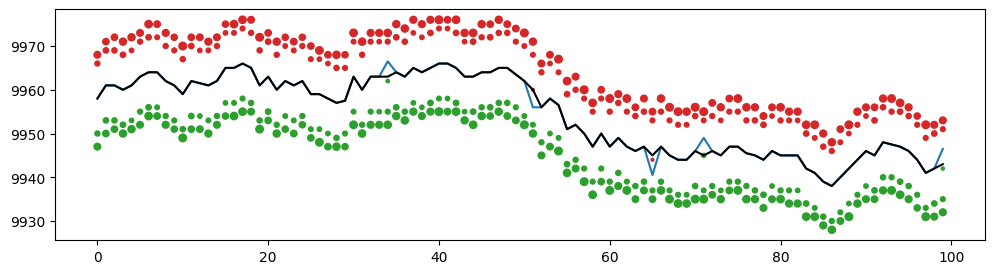

In [8]:
l = 100
plt.figure(figsize=(12, 3))
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['bid_price_1'], s=price_hydro.iloc[:l]['bid_volume_1'], c='tab:green')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['bid_price_2'], s=price_hydro.iloc[:l]['bid_volume_2'], c='tab:green')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['bid_price_3'], s=price_hydro.iloc[:l]['bid_volume_3'], c='tab:green')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['ask_price_1'], s=price_hydro.iloc[:l]['ask_volume_1'], c='tab:red')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['ask_price_2'], s=price_hydro.iloc[:l]['ask_volume_2'], c='tab:red')
plt.scatter(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['ask_price_3'], s=price_hydro.iloc[:l]['ask_volume_3'], c='tab:red')
plt.plot(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['mid_price'])
plt.plot(price_hydro.iloc[:l]['timestamp']//100, price_hydro.iloc[:l]['filtered_mid'], c='k')
plt.show()

In [9]:
print(price_hydro['filtered_mid'].mean(), price_hydro_1['filtered_mid'].mean(), price_hydro_2['filtered_mid'].mean())
print(pd.concat([price_hydro['filtered_mid'], price_hydro_1['filtered_mid'], price_hydro_2['filtered_mid']]).reset_index(drop=True).mean())
print(price_hydro['filtered_mid'].std(), price_hydro_1['filtered_mid'].std(), price_hydro_2['filtered_mid'].std())
print(pd.concat([price_hydro['filtered_mid'], price_hydro_1['filtered_mid'], price_hydro_2['filtered_mid']]).reset_index(drop=True).std())

9992.0595 9989.4188 10002.5083
9994.6622
37.61826249466224 31.625143027773845 32.94419088521234
34.622735530580485


In [10]:
hydro_mean = 9995
hydro_std = 35

In [11]:
price_hydro = price_hydro.set_index('timestamp', drop=True)
price_hydro_1 = price_hydro_1.set_index('timestamp', drop=True)
price_hydro_2 = price_hydro_2.set_index('timestamp', drop=True)

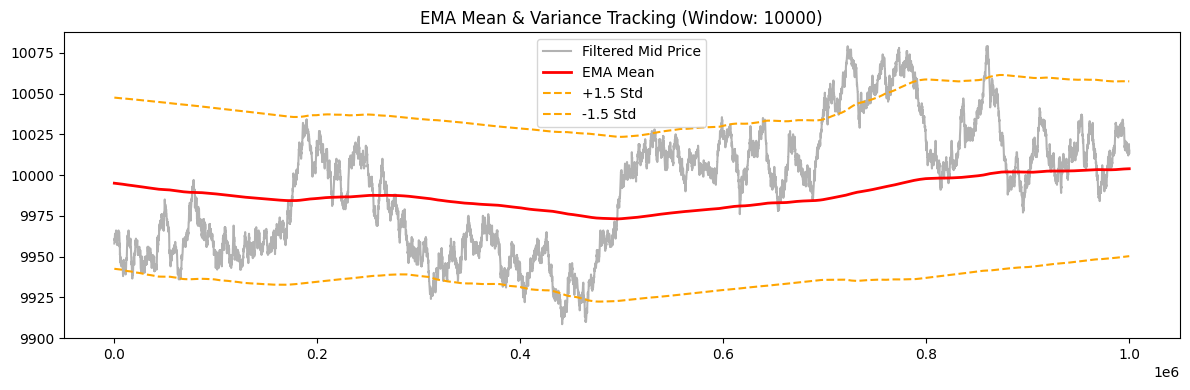

In [12]:
# 1. Initial States (Historical Hardcoded Values)
ema_mean = hydro_mean
ema_var = hydro_std ** 2

# 2. The Tuning Parameter (Equivalent to Q in the Kalman Filter)
# A smaller window adapts faster to regime shifts but is noisier.
# A larger window is more stubborn but slower to catch up to big moves.
window_size = 10000
alpha = 2 / (window_size + 1)

estimated_means = []
estimated_stds = []

# 3. EMA Updating Loop
for price in price_hydro['filtered_mid']:
    # Calculate difference from the *old* mean
    diff = price - ema_mean
    
    # Update Variance FIRST (Mathematically requires the difference from the old mean)
    ema_var = (1 - alpha) * ema_var + alpha * (diff ** 2)
    
    # Update Mean SECOND
    ema_mean = ema_mean + (alpha * diff)
    
    # Calculate instantaneous dynamic standard deviation
    current_std = math.sqrt(ema_var)
    
    estimated_means.append(ema_mean)
    estimated_stds.append(current_std)

# 4. Save to DataFrame
price_hydro['estimated_mean'] = estimated_means
price_hydro['estimated_std'] = estimated_stds

# 5. Plotting (With your exact 1.5 Std Dev bands)
plt.figure(figsize=(12, 4))
plt.plot(price_hydro['filtered_mid'], label='Filtered Mid Price', color='gray', alpha=0.6)
plt.plot(price_hydro['estimated_mean'], label='EMA Mean', color='red', linewidth=2)
plt.plot(price_hydro['estimated_mean'] + 1.5 * price_hydro['estimated_std'], color='orange', linestyle='--', label='+1.5 Std')
plt.plot(price_hydro['estimated_mean'] - 1.5 * price_hydro['estimated_std'], color='orange', linestyle='--', label='-1.5 Std')

plt.title(f'EMA Mean & Variance Tracking (Window: {window_size})')
plt.legend()
plt.tight_layout()
plt.show()

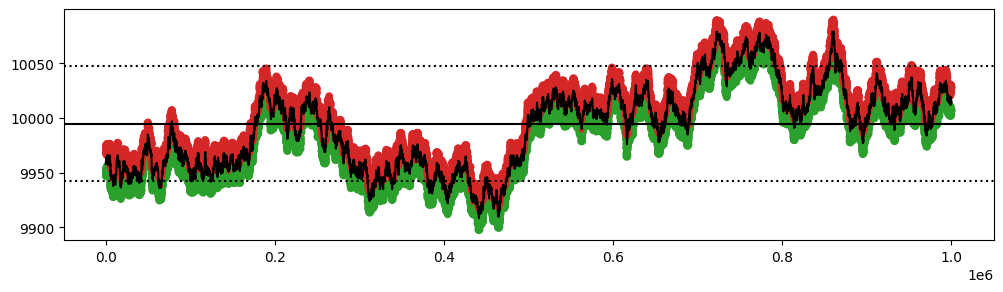

In [13]:
plt.figure(figsize=(12, 3))
plt.scatter(price_hydro.index, price_hydro['bid_price_1'], s=price_hydro['bid_volume_1'], c='tab:green')
plt.scatter(price_hydro.index, price_hydro['bid_price_2'], s=price_hydro['bid_volume_2'], c='tab:green')
plt.scatter(price_hydro.index, price_hydro['bid_price_3'], s=price_hydro['bid_volume_3'], c='tab:green')
plt.scatter(price_hydro.index, price_hydro['ask_price_1'], s=price_hydro['ask_volume_1'], c='tab:red')
plt.scatter(price_hydro.index, price_hydro['ask_price_2'], s=price_hydro['ask_volume_2'], c='tab:red')
plt.scatter(price_hydro.index, price_hydro['ask_price_3'], s=price_hydro['ask_volume_3'], c='tab:red')
plt.plot(price_hydro.index, price_hydro['filtered_mid'], c='k')
plt.axhline(hydro_mean, c='k')
plt.axhline(hydro_mean + 1.5 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean - 1.5 * hydro_std, c='k', linestyle='dotted')
plt.show()

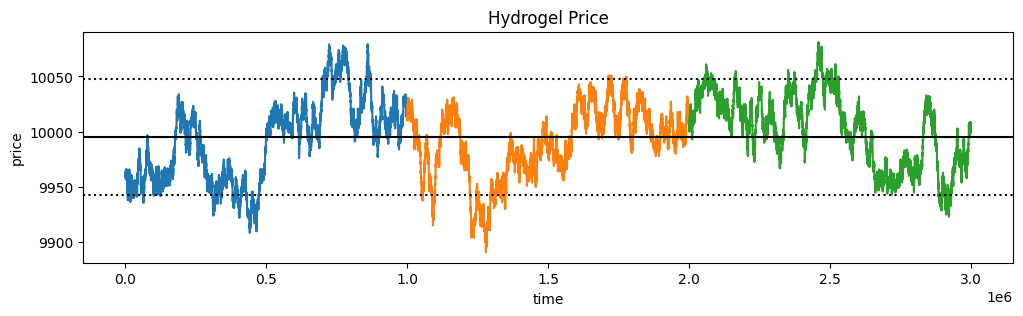

In [14]:
plt.figure(figsize=(12, 3))
plt.plot(price_hydro.index, price_hydro['filtered_mid'])
plt.plot(price_hydro_1.index + 1000000, price_hydro_1['filtered_mid'])
plt.plot(price_hydro_2.index + 2000000, price_hydro_2['filtered_mid'])
plt.axhline(hydro_mean, c='k')
plt.axhline(hydro_mean + 1.5 * hydro_std, c='k', linestyle='dotted')
plt.axhline(hydro_mean - 1.5 * hydro_std, c='k', linestyle='dotted')
plt.title('Hydrogel Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [15]:
imbalance = (price_hydro.fillna(0)['bid_volume_2'] + price_hydro.fillna(0)['bid_volume_3']) / \
    (price_hydro.fillna(0)['bid_volume_2'] + price_hydro.fillna(0)['bid_volume_3'] + \
     price_hydro.fillna(0)['ask_volume_2'] + price_hydro.fillna(0)['ask_volume_3'])
price_hydro = price_hydro.assign(imbalance=imbalance)

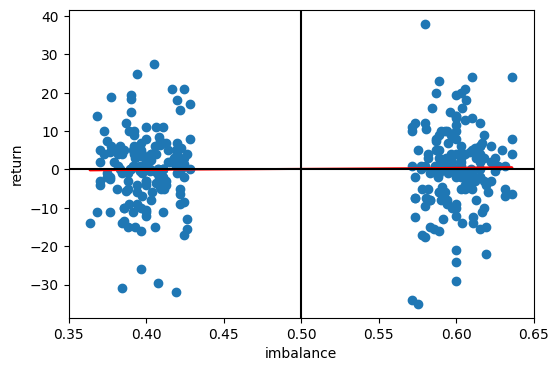

In [16]:
y = price_hydro[(price_hydro['imbalance'] > 0.5) | (price_hydro['imbalance'] < 0.5)]['filtered_mid'].diff(periods=1).dropna()
x = price_hydro[(price_hydro['imbalance'] > 0.5) | (price_hydro['imbalance'] < 0.5)]['imbalance'].iloc[-len(y):]
m, c = np.polyfit(x, y, 1)

plt.figure(figsize=(6, 4))
plt.scatter(x, y)
plt.plot(x, m * x + c, c='r')
plt.axhline(0, c='k')
plt.axvline(0.5, c='k')
plt.xlabel('imbalance')
plt.ylabel('return')
plt.show()

In [17]:
train_logr = np.log(price_hydro['filtered_mid']).diff().dropna()
test_logr = np.log(price_hydro_1['filtered_mid']).diff().dropna()

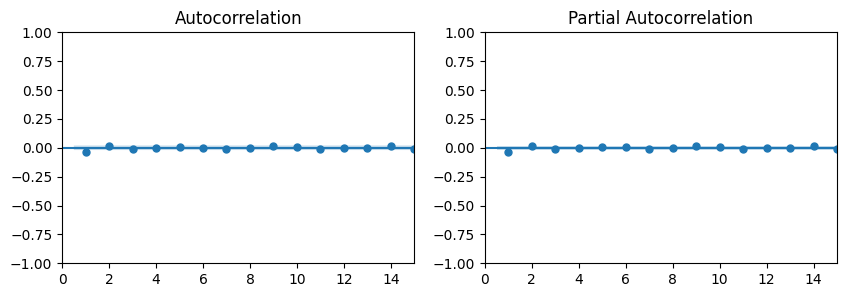

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [19]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

      lb_stat  lb_pvalue
10  21.881368    0.01572
Reject null hypothesis: data is not white noise.


In [20]:
true = test_logr[1:].to_numpy()

In [21]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.0002823384078833315


In [22]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.04, b = 0.0
AR(1) RMSE: 0.0001963809263661627


# Trades

In [23]:
def calculate_participant_pnls(trades_df):
    """
    Calculates the PnL for each market participant from a trades DataFrame.
    """
    cash = {}
    positions = {}
    last_prices = {}

    # Helper function to initialize a trader if they haven't been seen yet
    def init_trader(trader_id):
        if trader_id not in cash:
            cash[trader_id] = 0.0
            positions[trader_id] = {}

    # 1. Process every trade sequentially
    for _, row in trades_df.iterrows():
        buyer = row['buyer']
        seller = row['seller']
        symbol = row['symbol']
        price = row['price']
        qty = row['quantity']

        init_trader(buyer)
        init_trader(seller)

        if symbol not in positions[buyer]:
            positions[buyer][symbol] = 0
        if symbol not in positions[seller]:
            positions[seller][symbol] = 0

        # Update Buyer (Loses cash, gains inventory)
        cash[buyer] -= price * qty
        positions[buyer][symbol] += qty

        # Update Seller (Gains cash, loses inventory)
        cash[seller] += price * qty
        positions[seller][symbol] -= qty

        # Track the most recent price to use for final valuation
        last_prices[symbol] = price

    # 2. Mark-to-Market (MTM) Valuation
    results = []
    for trader in cash.keys():
        trader_data = {
            'Trader': trader,
            'Ending_Cash': cash[trader]
        }
        
        mtm_portfolio_value = 0.0
        for symbol, pos in positions[trader].items():
            trader_data[f'{symbol}_Position'] = pos
            # Value the open position at the last traded price
            mtm_portfolio_value += pos * last_prices.get(symbol, 0)
            
        trader_data['Portfolio_Value'] = mtm_portfolio_value
        trader_data['Total_PnL'] = cash[trader] + mtm_portfolio_value
        
        results.append(trader_data)

    # 3. Format as a clean DataFrame
    results_df = pd.DataFrame(results)
    
    # Fill NaN positions with 0 for traders who didn't trade a specific symbol
    results_df = results_df.fillna(0) 
    
    # Sort by the most profitable traders
    results_df = results_df.sort_values('Total_PnL', ascending=False).reset_index(drop=True)
    
    return results_df, last_prices

In [24]:
trades = pd.read_csv('../data/raw/round_4/trades_round_4_day_1.csv', delimiter=';')
trades_hydro = trades[trades['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True)
trades_1 = pd.read_csv('../data/raw/round_4/trades_round_4_day_2.csv', delimiter=';')
trades_hydro_1 = trades_1[trades_1['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True)
trades_2 = pd.read_csv('../data/raw/round_4/trades_round_4_day_3.csv', delimiter=';')
trades_hydro_2 = trades_2[trades_2['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True)

In [25]:
pnls_df, final_prices = calculate_participant_pnls(trades_hydro)
print("Last Traded Prices used for MTM:", final_prices)
print("\nParticipant PnLs:")
print(pnls_df.to_string())

Last Traded Prices used for MTM: {'HYDROGEL_PACK': 10017.0}

Participant PnLs:
    Trader  Ending_Cash  HYDROGEL_PACK_Position  Portfolio_Value  Total_PnL
0  Mark 14     105085.0                      -9         -90153.0    14932.0
1  Mark 22     -40253.0                       4          40068.0     -185.0
2  Mark 38     -64832.0                       5          50085.0   -14747.0


In [26]:
whale = pnls_df.iloc[0]['Trader']
mid = pnls_df.iloc[1]['Trader']
retail = pnls_df.iloc[2]['Trader']
print(f"Whale: {whale} --  Mid: {mid}  --  Retail: {retail}")

Whale: Mark 14 --  Mid: Mark 22  --  Retail: Mark 38


In [27]:
whale_trades = trades_hydro[(trades_hydro['buyer'] == whale) | (trades_hydro['seller'] == whale)].set_index('timestamp', drop=True)
mid_trades = trades_hydro[(trades_hydro['buyer'] == mid) | (trades_hydro['seller'] == mid)].set_index('timestamp', drop=True)
retail_trades = trades_hydro[(trades_hydro['buyer'] == retail) | (trades_hydro['seller'] == retail)].set_index('timestamp', drop=True)

In [28]:
whale_buys = whale_trades[whale_trades['buyer'] == whale]
whale_sells = whale_trades[whale_trades['seller'] == whale]
mid_buys = mid_trades[mid_trades['buyer'] == mid]
mid_sells = mid_trades[mid_trades['seller'] == mid]
retail_buys = retail_trades[retail_trades['buyer'] == retail]
retail_sells = retail_trades[retail_trades['seller'] == retail]

In [31]:
ob_cols = price_hydro[['bid_price_1', 'ask_price_1', 'mid_price']]
whale_buys = whale_buys.join(ob_cols, how='left')
whale_sells = whale_sells.join(ob_cols, how='left')
mid_buys = mid_buys.join(ob_cols, how='left')
mid_sells = mid_sells.join(ob_cols, how='left')
retail_buys = retail_buys.join(ob_cols, how='left')
retail_sells = retail_sells.join(ob_cols, how='left')

In [32]:
for df in [whale_buys, retail_buys, mid_buys]:
    # Maker: Resting bid was hit (Bought at or below best bid)
    df['making'] = df['price'] <= df['bid_price_1']
    # Taker: Crossed spread to hit ask (Bought at or above best ask)
    df['taking'] = df['price'] >= df['ask_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(df['making'] | df['taking'])
    df.loc[unclassified, 'making'] = df.loc[unclassified, 'price'] < df.loc[unclassified, 'mid_price']
    df.loc[unclassified, 'taking'] = df.loc[unclassified, 'price'] > df.loc[unclassified, 'mid_price']
    
for df in [whale_sells, retail_sells, mid_sells]:
    # Maker: Resting ask was hit (Sold at or above best ask)
    df['making'] = df['price'] >= df['ask_price_1']
    # Taker: Crossed spread to hit bid (Sold at or below best bid)
    df['taking'] = df['price'] <= df['bid_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(df['making'] | df['taking'])
    df.loc[unclassified, 'making'] = df.loc[unclassified, 'price'] > df.loc[unclassified, 'mid_price']
    df.loc[unclassified, 'taking'] = df.loc[unclassified, 'price'] < df.loc[unclassified, 'mid_price']

cols_to_drop = ['bid_price_1', 'ask_price_1', 'mid_price']
whale_buys.drop(columns=cols_to_drop, inplace=True)
whale_sells.drop(columns=cols_to_drop, inplace=True)
mid_buys.drop(columns=cols_to_drop, inplace=True)
mid_sells.drop(columns=cols_to_drop, inplace=True)
retail_buys.drop(columns=cols_to_drop, inplace=True)
retail_sells.drop(columns=cols_to_drop, inplace=True)

In [33]:
mid_trades.shape

(5, 6)

In [34]:
whale_buys['making'].sum(), whale_buys['taking'].sum(), whale_sells['making'].sum(), whale_sells['taking'].sum()

(np.int64(183), np.int64(0), np.int64(187), np.int64(0))

In [35]:
retail_buys['making'].sum(), retail_buys['taking'].sum(), retail_sells['making'].sum(), retail_sells['taking'].sum()

(np.int64(0), np.int64(189), np.int64(0), np.int64(186))

In [36]:
mid_buys['making'].sum(), mid_buys['taking'].sum(), mid_sells['making'].sum(), mid_sells['taking'].sum()

(np.int64(3), np.int64(0), np.int64(2), np.int64(0))

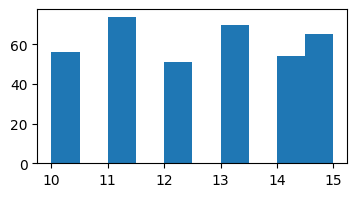

In [44]:
whale_full_quotes = []
for ts in whale_buys.index:
    whale_full_quotes.append(price_hydro.loc[ts, 'bid_volume_1'])
for ts in whale_sells.index:
    whale_full_quotes.append(price_hydro.loc[ts, 'ask_volume_1'])
plt.figure(figsize=(4, 2))
plt.hist(whale_full_quotes)
plt.show()

In [53]:
print(f"Whale's quoting band: [{min(whale_full_quotes)}, {max(whale_full_quotes)}]")

Whale's quoting band: [10, 15]


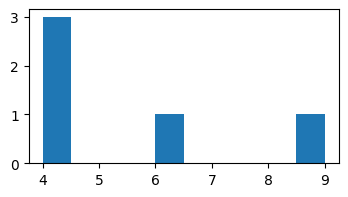

In [45]:
mid_full_quotes = []
for ts in mid_buys.index:
    mid_full_quotes.append(price_hydro.loc[ts, 'bid_volume_1'])
for ts in mid_sells.index:
    mid_full_quotes.append(price_hydro.loc[ts, 'ask_volume_1'])
plt.figure(figsize=(4, 2))
plt.hist(mid_full_quotes)
plt.show()

In [54]:
print(f"Mid's quoting band: [{min(mid_full_quotes)}, {max(mid_full_quotes)}]")

Mid's quoting band: [4, 9]


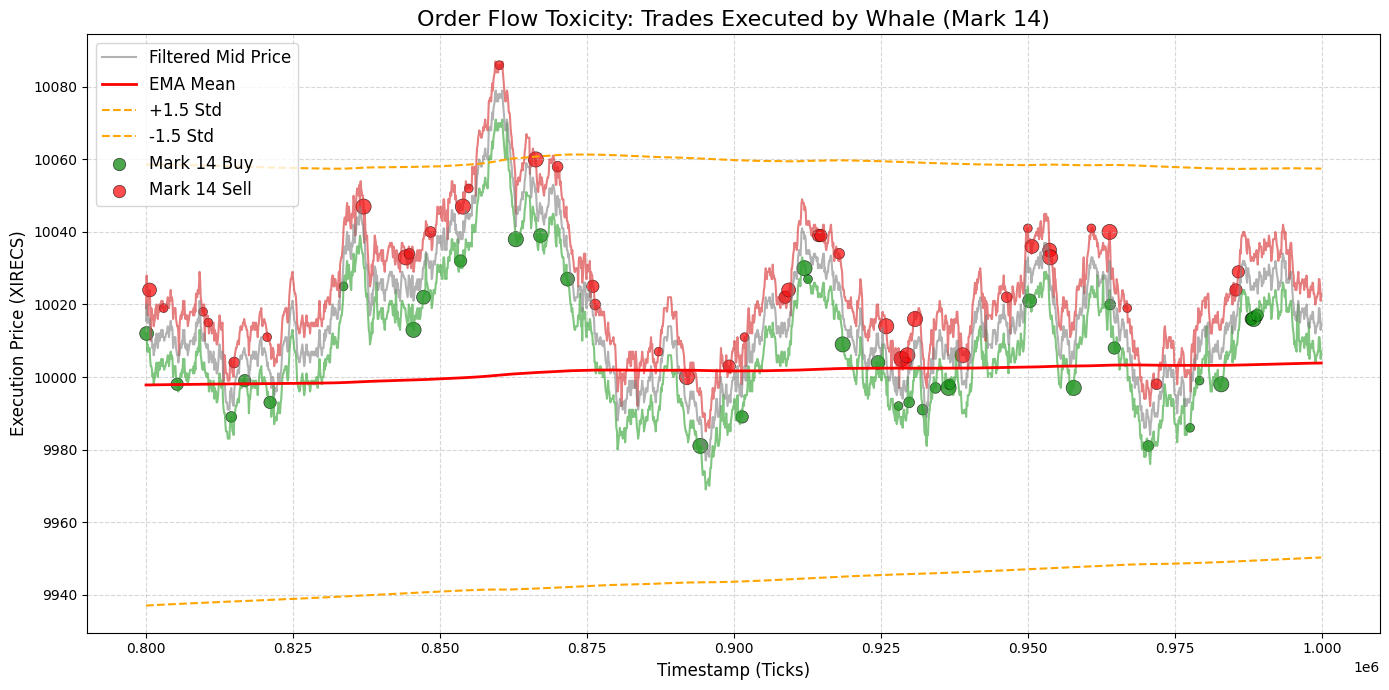

In [37]:
t1 = 800_000
t2 = 1000_000

plt.figure(figsize=(14, 7))
plt.plot(price_hydro.loc[t1:t2].index, price_hydro['bid_price_1'].loc[t1:t2], c='tab:green', alpha=0.6)
plt.plot(price_hydro.loc[t1:t2].index, price_hydro['ask_price_1'].loc[t1:t2], c='tab:red', alpha=0.6)
plt.plot(price_hydro['filtered_mid'].loc[t1:t2], label='Filtered Mid Price', color='gray', alpha=0.6)
plt.plot(price_hydro['estimated_mean'].loc[t1:t2], label='EMA Mean', color='red', linewidth=2)
plt.plot(price_hydro['estimated_mean'].loc[t1:t2] + 1.5 * price_hydro['estimated_std'].loc[t1:t2], color='orange', linestyle='--', label='+1.5 Std')
plt.plot(price_hydro['estimated_mean'].loc[t1:t2] - 1.5 * price_hydro['estimated_std'].loc[t1:t2], color='orange', linestyle='--', label='-1.5 Std')

size_multiplier = 20 
plt.scatter(
    whale_buys.loc[t1:t2].index, 
    whale_buys.loc[t1:t2]['price'], 
    s=whale_buys.loc[t1:t2]['quantity'] * size_multiplier, 
    color='green', 
    alpha=0.7, 
    edgecolors='black',
    linewidth=0.5,
    label=f'{whale} Buy'
)
plt.scatter(
    whale_sells.loc[t1:t2].index, 
    whale_sells.loc[t1:t2]['price'], 
    s=whale_sells.loc[t1:t2]['quantity'] * size_multiplier, 
    color='red', 
    alpha=0.7, 
    edgecolors='black',
    linewidth=0.5,
    label=f'{whale} Sell'
)
plt.title(f'Order Flow Toxicity: Trades Executed by Whale ({whale})', fontsize=16)
plt.xlabel('Timestamp (Ticks)', fontsize=12)
plt.ylabel('Execution Price (XIRECS)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
lgnd = plt.legend(loc="upper left", scatterpoints=1, fontsize=12)
lgnd.legend_handles[0]._sizes = [100]
lgnd.legend_handles[1]._sizes = [100]
plt.tight_layout()
plt.show()